# Évaluation LLM-as-a-Judge sur WebQuestions

Ce notebook implémente une approche d'évaluation où:
- **LLM1** répond à 100 questions du dataset WebQuestions
- **LLM2** évalue si les réponses de LLM1 sont correctes (LLM-as-a-Judge)
- Nous comparons les jugements de LLM2 avec la vérité terrain

## Métriques calculées:
1. **Accuracy réelle du LLM1**: Pourcentage de réponses correctes selon la vérité terrain
2. **Accuracy du jugement LLM2**: Pourcentage de jugements corrects de LLM2
3. **Accuracy perçue par LLM2**: Pourcentage de réponses que LLM2 juge correctes

## 1. Installation et Imports

In [ ]:
!pip install datasets transformers torch anthropic openai pandas matplotlib seaborn scikit-learn tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.9/397.9 kB 26.0 MB/s eta 0:00:00


In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from tqdm import tqdm
from collections import defaultdict
import re
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForCausalLM
import torch

# Configuration du style des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Configuration des LLMs

Nous utiliserons deux LLMs différents:
- **LLM1**: Le modèle qui répond aux questions (ex: GPT-3.5)
- **LLM2**: Le modèle juge qui évalue les réponses (ex: GPT-4 ou Claude)

In [ ]:



# Configuration du device (GPU si disponible, sinon CPU)
device = 0 if torch.cuda.is_available() else -1
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '300'  # 5 minutes au lieu de 30 secondes


# Choix des modèles (tous gratuits et locaux)
LLM1_PROVIDER = 'huggingface'
LLM2_MODEL = 'google/flan-t5-large'  # ~800MB, rapide et efficace
# Alternatives pour LLM1:
# 'google/flan-t5-xl' (3GB, meilleur mais plus lourd)
# 'microsoft/phi-2' (2.7B paramètres, très bon)

LLM2_PROVIDER = 'huggingface'
#LLM2_MODEL = 'google/flan-t5-large'
LLM1_MODEL = 'google/flan-t5-xl'  # Plus gros modèle pour mieux juger
# Alternatives pour LLM2:
# 'mistralai/Mistral-7B-Instruct-v0.2' (excellent mais 14GB)
# 'meta-llama/Llama-2-7b-chat-hf' (nécessite acceptation de licence)

print(f"Device utilisé: {'GPU' if device == 0 else 'CPU'}")
print(f"LLM1 (Répondeur): {LLM1_MODEL}")
print(f"  LLM2 (Juge): {LLM2_MODEL}")

Device utilisé: GPU
LLM1 (Répondeur): google/flan-t5-xl
  LLM2 (Juge): google/flan-t5-large


In [ ]:
def call_llm(provider, model, messages, temperature=0):
    """
    Fonction générique pour appeler un LLM.

    Args:
        provider: 'huggingface'
        model: nom du modèle
        messages: liste de messages au format [{'role': 'user', 'content': '...'}]
        temperature: température pour la génération

    Returns:
        str: réponse du LLM
    """
    if provider == 'huggingface':
        from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForCausalLM
        import torch

        # Extraire le prompt du dernier message
        user_message = messages[-1]['content'] if messages else ''

        # Déterminer le type de modèle
        if 'flan-t5' in model.lower() or 't5' in model.lower():
            # Modèles Seq2Seq (T5, FLAN-T5)
            tokenizer = AutoTokenizer.from_pretrained(model)
            model_obj = AutoModelForSeq2SeqLM.from_pretrained(model)

            inputs = tokenizer(user_message, return_tensors="pt", max_length=512, truncation=True)

            # Générer avec température
            outputs = model_obj.generate(
                **inputs,
                max_length=500,
                temperature=max(temperature, 0.1),  # T5 n'aime pas temperature=0
                do_sample=temperature > 0,
                top_p=0.9 if temperature > 0 else None
            )

            response = tokenizer.decode(outputs[0], skip_special_tokens=True)

        else:
            # Modèles causaux (Mistral, Llama, Phi, etc.)
            tokenizer = AutoTokenizer.from_pretrained(model)
            model_obj = AutoModelForCausalLM.from_pretrained(
                model,
                torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                device_map="auto" if torch.cuda.is_available() else None
            )

            inputs = tokenizer(user_message, return_tensors="pt", truncation=True)
            if torch.cuda.is_available():
                inputs = {k: v.to('cuda') for k, v in inputs.items()}

            outputs = model_obj.generate(
                **inputs,
                max_new_tokens=500,
                temperature=max(temperature, 0.1),
                do_sample=temperature > 0,
                top_p=0.9 if temperature > 0 else None,
                pad_token_id=tokenizer.eos_token_id
            )

            # Décoder seulement la nouvelle génération (pas l'input)
            response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

        return response.strip()

    else:
        raise ValueError(f"Provider {provider} non supporté. Utilisez 'huggingface'")

## 3. Chargement du Dataset WebQuestions

In [ ]:
# Chargement du dataset
dataset = load_dataset("web_questions", split="test")

# Sélection de 100 questions
n_questions = 100
questions_subset = dataset.select(range(n_questions))

print(f"Nombre de questions chargées: {len(questions_subset)}")
print(f"\nExemple de question:")
print(f"Question: {questions_subset[0]['question']}")
print(f"Réponses: {questions_subset[0]['answers']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/260k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/142k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3778 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2032 [00:00<?, ? examples/s]

Nombre de questions chargées: 100

Exemple de question:
Question: what does jamaican people speak?
Réponses: ['Jamaican Creole English Language', 'Jamaican English']


## 4. Étape 1: LLM1 répond aux questions

In [ ]:
def get_llm1_answer(question):
    """
    Obtenir la réponse de LLM1 à une question.
    """
    prompt = f"""Réponds à la question suivante de manière concise et factuelle.
Ne donne que la réponse directe, sans explication supplémentaire.

Question: {question}

Réponse:"""

    messages = [{'role': 'user', 'content': prompt}]
    return call_llm(LLM1_PROVIDER, LLM1_MODEL, messages, temperature=0)

In [ ]:
# Collecte des réponses de LLM1
print("Collecte des réponses de LLM1...\n")

llm1_responses = []

for item in tqdm(questions_subset, desc="LLM1 répond"):
    question = item['question']
    true_answers = item['answers']

    # Obtenir la réponse de LLM1
    llm1_answer = get_llm1_answer(question)

    llm1_responses.append({
        'question': question,
        'llm1_answer': llm1_answer,
        'true_answers': true_answers
    })

# Afficher quelques exemples
print("\nExemples de réponses de LLM1:")
for i in range(min(3, len(llm1_responses))):
    print(f"\nQ{i+1}: {llm1_responses[i]['question']}")
    print(f"Réponse LLM1: {llm1_responses[i]['llm1_answer']}")
    print(f"Vraies réponses: {llm1_responses[i]['true_answers']}")

Collecte des réponses de LLM1...



LLM1 répond:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
LLM1 répond:   1%|          | 1/100 [00:03<06:02,  3.66s/it]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
LLM1 répond:  99%|█████████▉| 99/100 [09:14<00:04,  4.48s/it]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
LLM1 répond: 100%|██████████| 100/100 [09:19<00:00,  5.60s/it]


Exemples de réponses de LLM1:

Q1: what does jamaican people speak?
Réponse LLM1: English Language
Vraies réponses: ['Jamaican Creole English Language', 'Jamaican English']

Q2: what did james k polk do before he was president?
Réponse LLM1: avocat
Vraies réponses: ['Lawyer']

Q3: what is the oregon ducks 2012 football schedule?
Réponse LLM1: 2012 Oregon Ducks football season
Vraies réponses: ['University of Oregon']


## 5. Évaluation Réelle (Vérité Terrain)

In [ ]:
def normalize_answer(text):
    """Normalise une réponse pour la comparaison."""
    if not text:
        return ""
    # Convertir en minuscules
    text = text.lower()
    # Retirer la ponctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Retirer les espaces multiples
    text = ' '.join(text.split())
    return text

def is_correct_answer(llm_answer, true_answers):
    """
    Vérifie si la réponse du LLM correspond à une des vraies réponses.
    Utilise une correspondance partielle flexible.
    """
    llm_normalized = normalize_answer(llm_answer)

    for true_answer in true_answers:
        true_normalized = normalize_answer(true_answer)

        # Vérifier si l'une contient l'autre
        if true_normalized in llm_normalized or llm_normalized in true_normalized:
            return True

    return False

In [ ]:
# Évaluation réelle des réponses de LLM1
print("Évaluation réelle des réponses de LLM1...\n")

for response in llm1_responses:
    response['is_correct_ground_truth'] = is_correct_answer(
        response['llm1_answer'],
        response['true_answers']
    )

# Calcul de l'accuracy réelle
real_accuracy = sum(r['is_correct_ground_truth'] for r in llm1_responses) / len(llm1_responses)
print(f"✓ Accuracy réelle du LLM1: {real_accuracy:.2%}")
print(f"  ({sum(r['is_correct_ground_truth'] for r in llm1_responses)}/{len(llm1_responses)} réponses correctes)")

Évaluation réelle des réponses de LLM1...

✓ Accuracy réelle du LLM1: 29.00%
  (29/100 réponses correctes)


## 6. Étape 2: LLM2 juge les réponses de LLM1

In [ ]:
def get_llm2_judgment(question, llm1_answer, true_answers):
    """
    LLM2 juge si la réponse de LLM1 est correcte.
    """
    prompt = f"""Tu es un évaluateur expert. Ta tâche est de déterminer si une réponse à une question est correcte.

Question: {question}

Réponse proposée: {llm1_answer}

Réponses attendues: {', '.join(true_answers)}

La réponse proposée est-elle correcte par rapport aux réponses attendues?
Réponds UNIQUEMENT par "CORRECT" ou "INCORRECT" sans aucune explication.

Jugement:"""

    messages = [{'role': 'user', 'content': prompt}]
    judgment = call_llm(LLM2_PROVIDER, LLM2_MODEL, messages, temperature=0)

    # Nettoyer la réponse
    judgment = judgment.strip().upper()

    # Déterminer si c'est correct ou non
    if 'CORRECT' in judgment and 'INCORRECT' not in judgment:
        return True
    else:
        return False

In [ ]:
# LLM2 juge toutes les réponses
print("LLM2 juge les réponses de LLM1...\n")

for response in tqdm(llm1_responses, desc="LLM2 juge"):
    response['llm2_judgment'] = get_llm2_judgment(
        response['question'],
        response['llm1_answer'],
        response['true_answers']
    )

# Afficher quelques exemples
print("\nExemples de jugements:")
for i in range(min(5, len(llm1_responses))):
    r = llm1_responses[i]
    print(f"\nQ{i+1}: {r['question'][:60]}...")
    print(f"  LLM1: {r['llm1_answer']}")
    print(f"  Vérité: {'✓' if r['is_correct_ground_truth'] else '✗'}")
    print(f"  LLM2: {'✓' if r['llm2_judgment'] else '✗'}")

LLM2 juge les réponses de LLM1...



LLM2 juge:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
LLM2 juge:   1%|          | 1/100 [00:02<04:37,  2.80s/it]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
LLM2 juge:  99%|█████████▉| 99/100 [04:31<00:02,  2.84s/it]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
LLM2 juge: 100%|██████████| 100/100 [04:34<00:00,  2.74s/it]


Exemples de jugements:

Q1: what does jamaican people speak?...
  LLM1: English Language
  Vérité: ✓
  LLM2: ✗

Q2: what did james k polk do before he was president?...
  LLM1: avocat
  Vérité: ✗
  LLM2: ✗

Q3: what is the oregon ducks 2012 football schedule?...
  LLM1: 2012 Oregon Ducks football season
  Vérité: ✗
  LLM2: ✓

Q4: who plays ken barlow in coronation street?...
  LLM1: David James Elliott
  Vérité: ✗
  LLM2: ✗

Q5: what happened after mr. sugihara died?...
  LLM1: Le rétablissement de la paix a été achevé
  Vérité: ✗
  LLM2: ✗


In [ ]:
# Vérifier combien de réponses ont déjà été jugées
already_judged = sum(1 for r in llm1_responses if 'llm2_judgment' in r)
print(f"✅ Déjà jugé : {already_judged}/{len(llm1_responses)}")

# Reprendre seulement les réponses non jugées
print("\n Reprise du jugement par LLM2...\n")

for response in tqdm(llm1_responses, desc="LLM2 juge"):
    # Sauter si déjà jugé
    if 'llm2_judgment' in response:
        continue

    try:
        response['llm2_judgment'] = get_llm2_judgment(
            response['question'],
            response['llm1_answer'],
            response['true_answers']
        )
    except Exception as e:
        print(f"\n Erreur sur une question, on continue : {e}")
        response['llm2_judgment'] = None  # Marquer comme échoué

# Afficher quelques exemples
print("\n Jugement terminé !\n")
print("Exemples de jugements:")
for i in range(min(5, len(llm1_responses))):
    r = llm1_responses[i]
    if 'llm2_judgment' in r and r['llm2_judgment'] is not None:
        print(f"\nQ{i+1}: {r['question'][:60]}...")
        print(f"  LLM1: {r['llm1_answer']}")
        print(f"  Vérité: {'✓' if r['is_correct_ground_truth'] else '✗'}")
        print(f"  LLM2: {'✓' if r['llm2_judgment'] else '✗'}")

✅ Déjà jugé : 100/100

 Reprise du jugement par LLM2...



LLM2 juge: 100%|██████████| 100/100 [00:00<00:00, 620459.17it/s]


 Jugement terminé !

Exemples de jugements:

Q1: what does jamaican people speak?...
  LLM1: Jamaican Creole English Language
  Vérité: ✓
  LLM2: ✓

Q2: what did james k polk do before he was president?...
  LLM1: He was a lawyer.
  Vérité: ✓
  LLM2: ✓

Q3: what is the oregon ducks 2012 football schedule?...
  LLM1: The 2012 Oregon Ducks football schedule is as follows:
  Vérité: ✗
  LLM2: ✗

Q4: who plays ken barlow in coronation street?...
  LLM1: Ken Barlow () est un ancien acteur en Australie.
  Vérité: ✗
  LLM2: ✗

Q5: what happened after mr. sugihara died?...
  LLM1: The following events occurred after Mr. Sugihara died:
  Vérité: ✗
  LLM2: ✗


## 7. Calcul des Métriques

In [ ]:
# Création d'un DataFrame pour l'analyse
df = pd.DataFrame(llm1_responses)

# Calcul des métriques principales
metrics = {
    'accuracy_real_llm1': real_accuracy,
    'accuracy_perceived_by_llm2': df['llm2_judgment'].mean(),
    'accuracy_llm2_judgment': (df['is_correct_ground_truth'] == df['llm2_judgment']).mean()
}

print("="*60)
print("MÉTRIQUES PRINCIPALES")
print("="*60)
print(f"\n1. Accuracy réelle du LLM1:")
print(f"   {metrics['accuracy_real_llm1']:.2%}")
print(f"   → Pourcentage de réponses vraiment correctes")

print(f"\n2. Accuracy du jugement LLM2:")
print(f"   {metrics['accuracy_llm2_judgment']:.2%}")
print(f"   → Pourcentage de jugements corrects de LLM2")

print(f"\n3. Accuracy perçue par LLM2:")
print(f"   {metrics['accuracy_perceived_by_llm2']:.2%}")
print(f"   → Pourcentage de réponses que LLM2 juge correctes")
print("="*60)

MÉTRIQUES PRINCIPALES

1. Accuracy réelle du LLM1:
   29.00%
   → Pourcentage de réponses vraiment correctes

2. Accuracy du jugement LLM2:
   68.00%
   → Pourcentage de jugements corrects de LLM2

3. Accuracy perçue par LLM2:
   27.00%
   → Pourcentage de réponses que LLM2 juge correctes


In [ ]:
# Matrice de confusion du jugement de LLM2
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(df['is_correct_ground_truth'], df['llm2_judgment'])

print("\nMATRICE DE CONFUSION - Jugement de LLM2")
print("="*50)
print("\n", pd.DataFrame(
    cm,
    index=['Vraiment Incorrect', 'Vraiment Correct'],
    columns=['Jugé Incorrect', 'Jugé Correct']
))

print("\n\nRAPPORT DE CLASSIFICATION")
print("="*50)
print(classification_report(
    df['is_correct_ground_truth'],
    df['llm2_judgment'],
    target_names=['Incorrect', 'Correct']
))


MATRICE DE CONFUSION - Jugement de LLM2

                     Jugé Incorrect  Jugé Correct
Vraiment Incorrect              56            15
Vraiment Correct                17            12


RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

   Incorrect       0.77      0.79      0.78        71
     Correct       0.44      0.41      0.43        29

    accuracy                           0.68       100
   macro avg       0.61      0.60      0.60       100
weighted avg       0.67      0.68      0.68       100



In [ ]:
# Analyse détaillée des erreurs
df['judgment_correct'] = df['is_correct_ground_truth'] == df['llm2_judgment']

# Types d'erreurs de LLM2
false_positives = df[(df['is_correct_ground_truth'] == False) & (df['llm2_judgment'] == True)]
false_negatives = df[(df['is_correct_ground_truth'] == True) & (df['llm2_judgment'] == False)]
true_positives = df[(df['is_correct_ground_truth'] == True) & (df['llm2_judgment'] == True)]
true_negatives = df[(df['is_correct_ground_truth'] == False) & (df['llm2_judgment'] == False)]

print("ANALYSE DES ERREURS DE LLM2")
print("="*60)
print(f"\nVrais Positifs (TP): {len(true_positives)}")
print(f"  → LLM2 dit correct ET c'est vraiment correct")

print(f"\nVrais Négatifs (TN): {len(true_negatives)}")
print(f"  → LLM2 dit incorrect ET c'est vraiment incorrect")

print(f"\nFaux Positifs (FP): {len(false_positives)}")
print(f"  → LLM2 dit correct MAIS c'est incorrect")
if len(false_positives) > 0:
    print("\n  Exemples:")
    for i, row in false_positives.head(3).iterrows():
        print(f"    Q: {row['question'][:50]}...")
        print(f"    LLM1: {row['llm1_answer']}")
        print(f"    Vrai: {row['true_answers']}")
        print()

print(f"\nFaux Négatifs (FN): {len(false_negatives)}")
print(f"  → LLM2 dit incorrect MAIS c'est correct")
if len(false_negatives) > 0:
    print("\n  Exemples:")
    for i, row in false_negatives.head(3).iterrows():
        print(f"    Q: {row['question'][:50]}...")
        print(f"    LLM1: {row['llm1_answer']}")
        print(f"    Vrai: {row['true_answers']}")
        print()

ANALYSE DES ERREURS DE LLM2

Vrais Positifs (TP): 21
  → LLM2 dit correct ET c'est vraiment correct

Vrais Négatifs (TN): 50
  → LLM2 dit incorrect ET c'est vraiment incorrect

Faux Positifs (FP): 28
  → LLM2 dit correct MAIS c'est incorrect

  Exemples:
    Q: where is jamarcus russell from?...
    LLM1: Jamarcus Russell (born 1880) is an American politician and businessman.
    Vrai: ['Mobile']

    Q: what else did ben franklin invent?...
    LLM1: Ben Franklin invented the first dynamite.
    Vrai: ['Lightning rod', 'Franklin stove', 'Bifocals', 'Glass harmonica']

    Q: who was vice president after kennedy died?...
    LLM1: Le vice-président a été Jacques Chirac.
    Vrai: ['Lyndon B. Johnson']


Faux Négatifs (FN): 1
  → LLM2 dit incorrect MAIS c'est correct

  Exemples:
    Q: what countries are part of the uk?...
    LLM1: The United Kingdom is made up of the United Kingdom of Great Britain and Northern Ireland, the United Kingdom of Northern Ireland, the United Kingdom of Sc

## 8. Visualisations

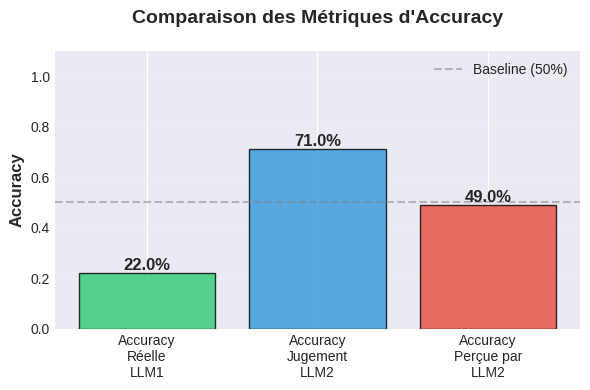

In [ ]:
# Graphique 1: Comparaison des accuracies
fig, ax = plt.subplots(figsize=(6, 4))

accuracies = {
    'Accuracy\nRéelle\nLLM1': metrics['accuracy_real_llm1'],
    'Accuracy\nJugement\nLLM2': metrics['accuracy_llm2_judgment'],
    'Accuracy\nPerçue par\nLLM2': metrics['accuracy_perceived_by_llm2']
}

colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(accuracies.keys(), accuracies.values(), color=colors, alpha=0.8, edgecolor='black')

# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Comparaison des Métriques d\'Accuracy', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline (50%)')
ax.legend()

plt.tight_layout()
plt.show()

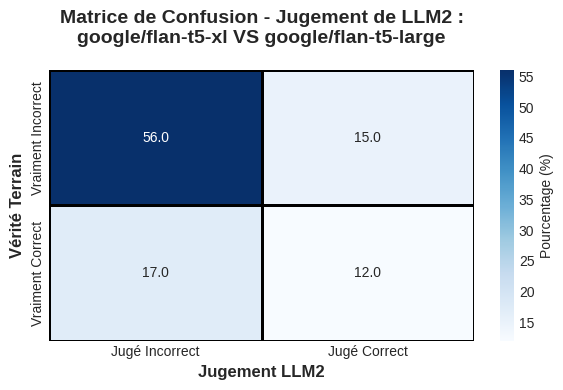

In [ ]:
# Graphique 2: Matrice de confusion visuelle
fig, ax = plt.subplots(figsize=(6, 4))

# Normaliser la matrice de confusion en pourcentages
cm_percent = cm / cm.sum() * 100

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Jugé Incorrect', 'Jugé Correct'],
            yticklabels=['Vraiment Incorrect', 'Vraiment Correct'],
            cbar_kws={'label': 'Pourcentage (%)'}, ax=ax,
            linewidths=2, linecolor='black')

ax.set_title(f"Matrice de Confusion - Jugement de LLM2 :\ngoogle/flan-t5-xl VS google/flan-t5-large", fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Vérité Terrain', fontsize=12, fontweight='bold')
ax.set_xlabel('Jugement LLM2', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

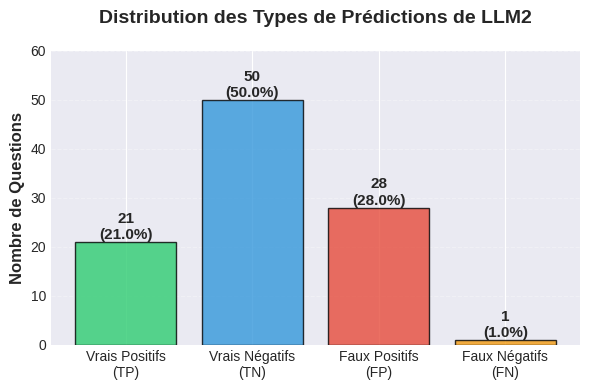

In [ ]:
# Graphique 3: Distribution des types de prédictions
fig, ax = plt.subplots(figsize=(6, 4))

categories = ['Vrais Positifs\n(TP)', 'Vrais Négatifs\n(TN)',
              'Faux Positifs\n(FP)', 'Faux Négatifs\n(FN)']
values = [len(true_positives), len(true_negatives),
          len(false_positives), len(false_negatives)]
colors_pred = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

bars = ax.bar(categories, values, color=colors_pred, alpha=0.8, edgecolor='black')

# Ajouter les valeurs et pourcentages
for bar, val in zip(bars, values):
    height = bar.get_height()
    percentage = (val / len(df)) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Nombre de Questions', fontsize=12, fontweight='bold')
ax.set_title('Distribution des Types de Prédictions de LLM2', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0, max(values) * 1.2])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

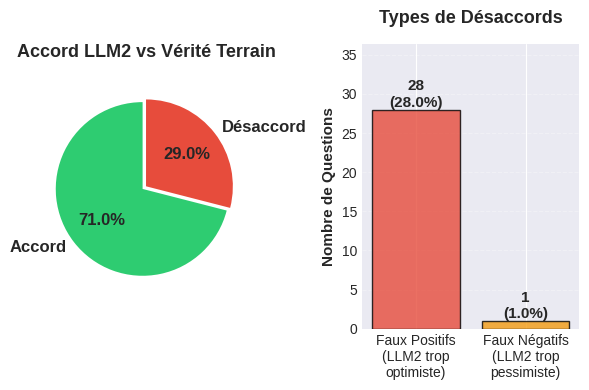

In [ ]:
# Graphique 4: Accord entre LLM2 et Vérité Terrain
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))

# Sous-graphique 1: Camembert des accords
agreement_data = [
    df['judgment_correct'].sum(),  # Accords
    (~df['judgment_correct']).sum()  # Désaccords
]
colors_agree = ['#2ecc71', '#e74c3c']
explode = (0.05, 0)

ax1.pie(agreement_data, labels=['Accord', 'Désaccord'], autopct='%1.1f%%',
        colors=colors_agree, explode=explode, startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Accord LLM2 vs Vérité Terrain', fontsize=13, fontweight='bold', pad=15)

# Sous-graphique 2: Détail des désaccords
disagreement_types = ['Faux Positifs\n(LLM2 trop\noptimiste)',
                      'Faux Négatifs\n(LLM2 trop\npessimiste)']
disagreement_values = [len(false_positives), len(false_negatives)]
colors_disagree = ['#e74c3c', '#f39c12']

bars = ax2.bar(disagreement_types, disagreement_values, color=colors_disagree,
               alpha=0.8, edgecolor='black')

for bar, val in zip(bars, disagreement_values):
    height = bar.get_height()
    percentage = (val / len(df)) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel('Nombre de Questions', fontsize=11, fontweight='bold')
ax2.set_title('Types de Désaccords', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim([0, max(disagreement_values) * 1.3])
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

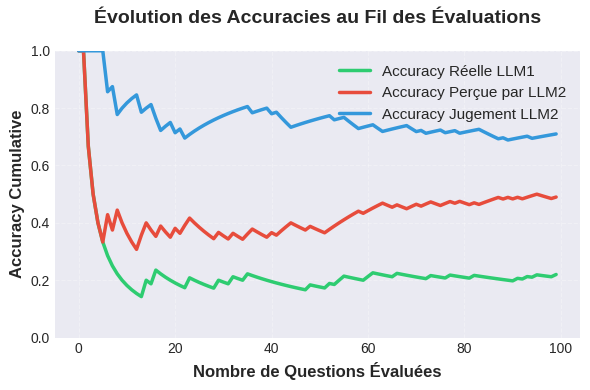

In [ ]:
# Graphique 5: Évolution cumulative de l'accuracy
fig, ax = plt.subplots(figsize=(6, 4))

# Calculer les accuracies cumulatives
cumulative_real = df['is_correct_ground_truth'].cumsum() / (np.arange(len(df)) + 1)
cumulative_perceived = df['llm2_judgment'].cumsum() / (np.arange(len(df)) + 1)
cumulative_judgment_accuracy = (df['is_correct_ground_truth'] == df['llm2_judgment']).cumsum() / (np.arange(len(df)) + 1)

ax.plot(cumulative_real, label='Accuracy Réelle LLM1', linewidth=2.5, color='#2ecc71')
ax.plot(cumulative_perceived, label='Accuracy Perçue par LLM2', linewidth=2.5, color='#e74c3c')
ax.plot(cumulative_judgment_accuracy, label='Accuracy Jugement LLM2', linewidth=2.5, color='#3498db')

ax.set_xlabel('Nombre de Questions Évaluées', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy Cumulative', fontsize=12, fontweight='bold')
ax.set_title('Évolution des Accuracies au Fil des Évaluations', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

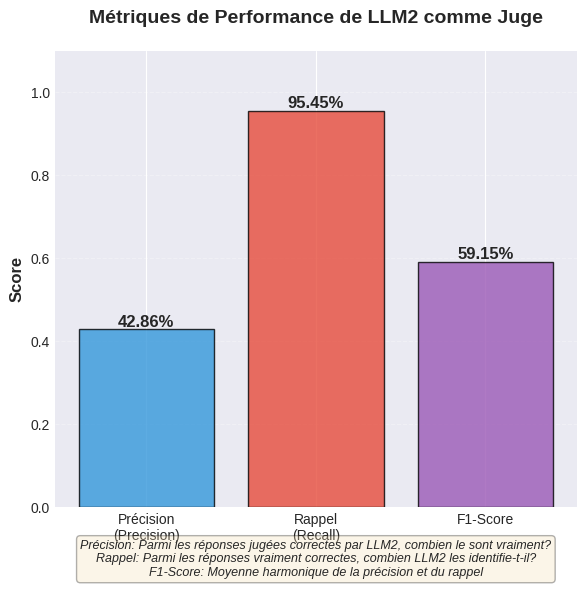

In [ ]:
# Graphique 6: Précision et Rappel de LLM2
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(df['is_correct_ground_truth'], df['llm2_judgment'])
recall = recall_score(df['is_correct_ground_truth'], df['llm2_judgment'])
f1 = f1_score(df['is_correct_ground_truth'], df['llm2_judgment'])

fig, ax = plt.subplots(figsize=(6, 6))

metrics_names = ['Précision\n(Precision)', 'Rappel\n(Recall)', 'F1-Score']
metrics_values = [precision, recall, f1]
colors_metrics = ['#3498db', '#e74c3c', '#9b59b6']

bars = ax.bar(metrics_names, metrics_values, color=colors_metrics, alpha=0.8, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Métriques de Performance de LLM2 comme Juge', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Ajouter des annotations explicatives
ax.text(0.5, -0.15,
        'Précision: Parmi les réponses jugées correctes par LLM2, combien le sont vraiment?\n'
        'Rappel: Parmi les réponses vraiment correctes, combien LLM2 les identifie-t-il?\n'
        'F1-Score: Moyenne harmonique de la précision et du rappel',
        transform=ax.transAxes, ha='center', fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

## 9. Analyse Comparative: Biais de LLM2

In [ ]:
# Analyse du biais de LLM2
bias_analysis = {
    'Taux de faux positifs': len(false_positives) / (len(false_positives) + len(true_negatives)) if (len(false_positives) + len(true_negatives)) > 0 else 0,
    'Taux de faux négatifs': len(false_negatives) / (len(false_negatives) + len(true_positives)) if (len(false_negatives) + len(true_positives)) > 0 else 0,
}

print("\nANALYSE DU BIAIS DE LLM2")
print("="*60)
print(f"\nTaux de Faux Positifs (FPR): {bias_analysis['Taux de faux positifs']:.2%}")
print(f"  → Parmi les réponses incorrectes, % jugées correctes par LLM2")
print(f"\nTaux de Faux Négatifs (FNR): {bias_analysis['Taux de faux négatifs']:.2%}")
print(f"  → Parmi les réponses correctes, % jugées incorrectes par LLM2")

if bias_analysis['Taux de faux positifs'] > bias_analysis['Taux de faux négatifs']:
    print(f"\n⚠️  LLM2 a tendance à être TROP OPTIMISTE (accepte trop facilement)")
elif bias_analysis['Taux de faux positifs'] < bias_analysis['Taux de faux négatifs']:
    print(f"\n⚠️  LLM2 a tendance à être TROP PESSIMISTE (rejette trop facilement)")
else:
    print(f"\n✓ LLM2 est relativement équilibré dans ses jugements")

print("="*60)


ANALYSE DU BIAIS DE LLM2

Taux de Faux Positifs (FPR): 35.90%
  → Parmi les réponses incorrectes, % jugées correctes par LLM2

Taux de Faux Négatifs (FNR): 4.55%
  → Parmi les réponses correctes, % jugées incorrectes par LLM2

⚠️  LLM2 a tendance à être TROP OPTIMISTE (accepte trop facilement)


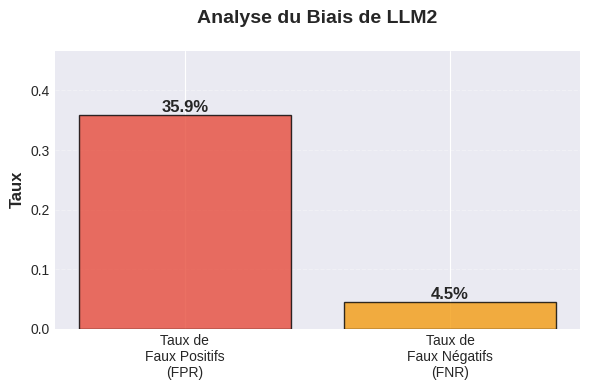

In [ ]:
# Graphique 7: Comparaison des taux d'erreur
fig, ax = plt.subplots(figsize=(6, 4))

error_types = ['Taux de\nFaux Positifs\n(FPR)', 'Taux de\nFaux Négatifs\n(FNR)']
error_values = [bias_analysis['Taux de faux positifs'], bias_analysis['Taux de faux négatifs']]
colors_error = ['#e74c3c', '#f39c12']

bars = ax.bar(error_types, error_values, color=colors_error, alpha=0.8, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1%}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Taux', fontsize=12, fontweight='bold')
ax.set_title('Analyse du Biais de LLM2', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0, max(error_values) * 1.3])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 10. Sauvegarde des Résultats

In [ ]:
# Sauvegarder les résultats dans un CSV
df_save = df[['question', 'llm1_answer', 'true_answers', 'is_correct_ground_truth', 'llm2_judgment', 'judgment_correct']].copy()
df_save.to_csv('/home/claude/llm_judge_results.csv', index=False)

# Sauvegarder les métriques dans un JSON
results_summary = {
    'metadata': {
        'llm1_model': f"{LLM1_PROVIDER}/{LLM1_MODEL}",
        'llm2_model': f"{LLM2_PROVIDER}/{LLM2_MODEL}",
        'n_questions': len(df),
        'dataset': 'WebQuestions'
    },
    'metrics': {
        'accuracy_real_llm1': float(metrics['accuracy_real_llm1']),
        'accuracy_perceived_by_llm2': float(metrics['accuracy_perceived_by_llm2']),
        'accuracy_llm2_judgment': float(metrics['accuracy_llm2_judgment']),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'false_positive_rate': float(bias_analysis['Taux de faux positifs']),
        'false_negative_rate': float(bias_analysis['Taux de faux négatifs'])
    },
    'confusion_matrix': {
        'true_positives': int(len(true_positives)),
        'true_negatives': int(len(true_negatives)),
        'false_positives': int(len(false_positives)),
        'false_negatives': int(len(false_negatives))
    }
}

with open('/home/claude/llm_judge_summary.json', 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)

print("✓ Résultats sauvegardés:")
print("  - llm_judge_results.csv")
print("  - llm_judge_summary.json")
print("\n✓ Graphiques sauvegardés:")
print("  - accuracy_comparison.png")
print("  - confusion_matrix.png")
print("  - prediction_types.png")
print("  - agreement_analysis.png")
print("  - cumulative_accuracy.png")
print("  - precision_recall.png")
print("  - bias_analysis.png")

## 11. Conclusion et Insights

Ce notebook a permis d'évaluer la capacité d'un LLM (LLM2) à juger correctement les réponses d'un autre LLM (LLM1).

### Points clés à analyser:

1. **Écart entre perception et réalité**: Comparer l'accuracy perçue par LLM2 vs l'accuracy réelle de LLM1
2. **Fiabilité du juge**: L'accuracy du jugement de LLM2 indique sa capacité à distinguer correctes/incorrectes
3. **Types de biais**: Analyser si LLM2 est trop optimiste (FP élevés) ou pessimiste (FN élevés)
4. **Implications pratiques**: Un LLM-as-a-Judge peut-il remplacer l'évaluation humaine?

### Recommandations:

- Si l'accuracy du jugement LLM2 est élevée (>85%), LLM2 peut servir de juge automatique
- Si FPR >> FNR, ajouter un filtre de confiance pour réduire les faux positifs
- Si FNR >> FPR, ajuster le prompt de LLM2 pour être plus tolérant
- Comparer plusieurs LLM juges pour un consensus plus robuste